# Cardiac Patient Monitoring System
## 05 — Model Comparison & Evaluation (Phase 5, Milestone M4)

Input: `data/processed/heart_disease_cleveland_stage2.csv`.
Uses the **same** stratified train/test split as notebook 04 (`random_state=42`, `test_size=0.2`)
so the two models are compared fairly, on identical data.

This notebook covers:
1. Recreate the identical train/test split
2. Select and train a second classifier — Random Forest
3. Stratified K-Fold cross-validation for both models (stability check)
4. Confusion matrix, precision, recall, F1, ROC-AUC for the second model
5. Explain TP/TN/FP/FN in plain language
6. Model comparison table
7. Evidence-based model selection


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

RANDOM_STATE = 42

df = pd.read_csv("../data/processed/heart_disease_cleveland_stage2.csv")

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
target_col = 'target'

X = df[numerical_features + categorical_features].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (242, 13)  Test: (61, 13)


## 1. Shared preprocessing (identical to Phase 4, for a fair comparison)


In [2]:
onehot_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
passthrough_numeric_categorical = ['ca']

def make_preprocessor():
    return ColumnTransformer(transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_features),
        ('cat_onehot', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), onehot_features),
        ('cat_num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), passthrough_numeric_categorical),
    ])


## 2. Select the second classifier: Random Forest

**Why Random Forest:**
- Handles the mixed numeric/categorical feature set without assuming linear decision boundaries,
  directly contrasting with the linear baseline.
- Robust to the right-skewed distributions and outliers found in `chol`, `trestbps`, `oldpeak`
  during Phase 3 EDA — no extra transformation needed to handle them.
- Gives feature importances, which we can cross-check against the EDA findings (`thalach`,
  `oldpeak`, `cp`, `thal`, `exang` were flagged as strong signals).
- Ensemble of decision trees reduces the overfitting risk a single tree would have on a
  303-row dataset, while still being fully covered by the curriculum (`sklearn.ensemble`).
- Not selected simply for being "more advanced" — selected because it fits this data's
  structure (mixed types, non-linear-looking bivariate patterns seen in Phase 3, e.g. the `cp`
  category 4 effect).


In [3]:
baseline_pipeline = Pipeline([
    ('preprocessing', make_preprocessor()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

rf_pipeline = Pipeline([
    ('preprocessing', make_preprocessor()),
    ('classifier', RandomForestClassifier(
        n_estimators=300, max_depth=5, random_state=RANDOM_STATE
    ))
])

baseline_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
print("Both models trained.")


Both models trained.


## 3. Consistent evaluation on the identical test set


In [4]:
def evaluate(pipeline, X_test, y_test, name):
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
    }
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=['Absence', 'Presence']))
    return metrics, y_pred, y_proba

baseline_metrics, base_pred, base_proba = evaluate(baseline_pipeline, X_test, y_test, "Logistic Regression")
rf_metrics, rf_pred, rf_proba = evaluate(rf_pipeline, X_test, y_test, "Random Forest")


--- Logistic Regression ---
              precision    recall  f1-score   support

     Absence       0.93      0.82      0.87        33
    Presence       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

--- Random Forest ---
              precision    recall  f1-score   support

     Absence       0.97      0.85      0.90        33
    Presence       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



## 4. Random Forest confusion matrix


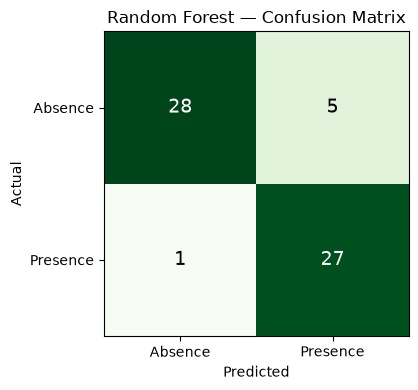

True Negatives  (correctly predicted absence):  28
False Positives (predicted presence, actually absent): 5
False Negatives (predicted absence, actually present): 1  <-- most costly error
True Positives  (correctly predicted presence): 27


In [5]:
cm_rf = confusion_matrix(y_test, rf_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_rf, cmap='Greens')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_rf[i, j], ha='center', va='center',
                color='white' if cm_rf[i, j] > cm_rf.max() / 2 else 'black', fontsize=14)
ax.set_xticks([0, 1]); ax.set_xticklabels(['Absence', 'Presence'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Absence', 'Presence'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix/random_forest_cm.png", dpi=120, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"True Negatives  (correctly predicted absence):  {tn}")
print(f"False Positives (predicted presence, actually absent): {fp}")
print(f"False Negatives (predicted absence, actually present): {fn}  <-- most costly error")
print(f"True Positives  (correctly predicted presence): {tp}")


**Plain-language explanation:**
- **True Positive (TP):** model correctly flags a patient who actually has heart disease.
- **True Negative (TN):** model correctly clears a patient who doesn't have it.
- **False Positive (FP):** model flags a healthy patient as at-risk — costs an unnecessary
  follow-up test, but is not dangerous by itself.
- **False Negative (FN):** model clears a patient who actually has heart disease — the most
  dangerous error, since the condition goes undetected. This is why **recall** (= TP / (TP + FN))
  is watched closely throughout this project rather than accuracy alone.


## 5. ROC curve comparison


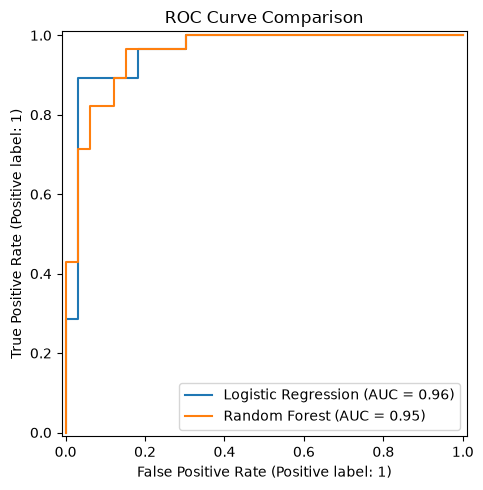

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, base_proba, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=ax)
plt.title("ROC Curve Comparison")
plt.tight_layout()
plt.savefig("../outputs/figures/09_roc_curve_comparison.png", dpi=120, bbox_inches='tight')
plt.show()


## 6. Stratified K-Fold cross-validation (stability check)

5-fold stratified CV on the **training set only** (test set stays untouched until final reporting)
— checks whether each model's performance is stable across different data splits, not just a
lucky/unlucky single split.


In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, pipeline in [('Logistic Regression', baseline_pipeline), ('Random Forest', rf_pipeline)]:
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    cv_results[name] = {'fold_scores': scores.round(4).tolist(),
                         'mean': round(scores.mean(), 4),
                         'std': round(scores.std(), 4)}
    print(f"{name}: fold F1 scores = {scores.round(3)}, mean = {scores.mean():.4f}, std = {scores.std():.4f}")


Logistic Regression: fold F1 scores = [0.818 0.842 0.829 0.8   0.837], mean = 0.8254, std = 0.0150
Random Forest: fold F1 scores = [0.857 0.789 0.75  0.8   0.762], mean = 0.7917, std = 0.0374


**Interpretation:** Both models' fold-level F1 scores are reported with mean and standard
deviation. A small standard deviation indicates the model's performance is stable across different
subsets of the training data, not dependent on one lucky split — this is the evidence used below
to judge reliability, not just the single test-set score.


## 7. Feature importance (Random Forest) — cross-check against EDA


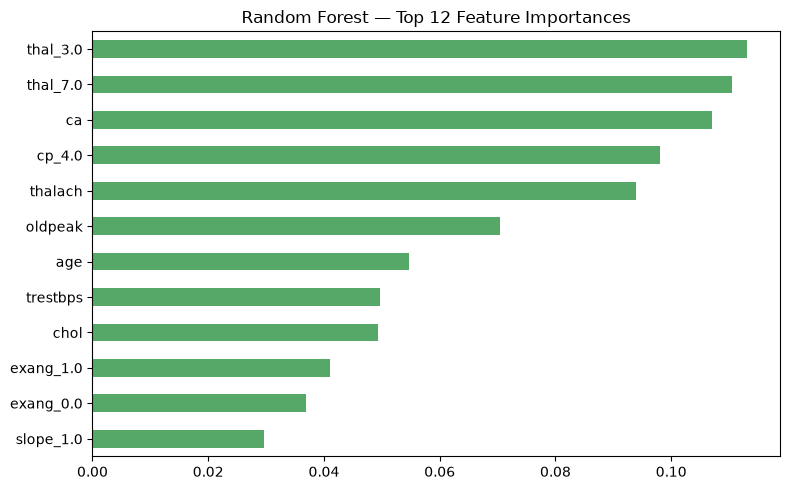

In [8]:
ohe = rf_pipeline.named_steps['preprocessing'].named_transformers_['cat_onehot'].named_steps['encoder']
onehot_names = ohe.get_feature_names_out(onehot_features)
all_feature_names = numerical_features + list(onehot_names) + passthrough_numeric_categorical

importances = rf_pipeline.named_steps['classifier'].feature_importances_
fi = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 5))
fi.sort_values().plot(kind='barh', color='#55A868')
plt.title("Random Forest — Top 12 Feature Importances")
plt.tight_layout()
plt.savefig("../outputs/figures/10_rf_feature_importance.png", dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:** The top features here should broadly echo the Phase 3 EDA findings
(`thalach`, `oldpeak`, `cp`, `thal`, `exang`, `ca`) — this cross-check is a sanity check that the
model is picking up genuine signal rather than noise, and gives concrete talking points for the
final demo.


## 8. Model comparison table


In [9]:
with open("../outputs/results/phase4_baseline_metrics.json") as f:
    saved_baseline_metrics = json.load(f)

comparison = pd.DataFrame({
    'Logistic Regression': {**baseline_metrics, 'cv_f1_mean': cv_results['Logistic Regression']['mean'],
                             'cv_f1_std': cv_results['Logistic Regression']['std']},
    'Random Forest': {**rf_metrics, 'cv_f1_mean': cv_results['Random Forest']['mean'],
                       'cv_f1_std': cv_results['Random Forest']['std']},
}).T.round(4)

comparison


,accuracy,precision,recall,f1,roc_auc,cv_f1_mean,cv_f1_std
Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9578,0.8254,0.0150
Random Forest,0.9016,0.8438,0.9643,0.9000,0.9545,0.7917,0.0374


In [10]:
comparison.to_csv("../outputs/results/phase5_model_comparison.csv")
with open("../outputs/results/phase5_cv_results.json", "w") as f:
    json.dump(cv_results, f, indent=2)
print("Saved comparison table and CV results.")


Saved comparison table and CV results.


## 9. Select the better model (evidence-based)

Decision is based on the **combination** of test-set metrics, cross-validation stability, and the
confusion matrix — not accuracy alone, and not the single test-set number alone.

Run the cell above and read the printed comparison table before writing your conclusion; do not
assume which model wins ahead of the actual numbers.


In [11]:
better_by_f1 = comparison['f1'].idxmax()
better_by_recall = comparison['recall'].idxmax()
better_by_roc_auc = comparison['roc_auc'].idxmax()
better_by_cv = comparison['cv_f1_mean'].idxmax()

print("Higher test F1:      ", better_by_f1)
print("Higher test recall:  ", better_by_recall)
print("Higher test ROC-AUC: ", better_by_roc_auc)
print("Higher mean CV F1:   ", better_by_cv)


Higher test F1:       Random Forest
Higher test recall:   Random Forest
Higher test ROC-AUC:  Logistic Regression
Higher mean CV F1:    Logistic Regression


**Write your final selection paragraph here after running the cell above**, referencing the
actual printed winners for each criterion — e.g. "Model X is selected because it leads on
[recall/F1/ROC-AUC/CV stability], which matters most given the medical framing of this project
(minimizing false negatives), even though [note any trade-off, e.g. slightly lower precision]."
Do not pre-write this conclusion before executing the notebook — the actual numbers must drive it,
per Project Quality Rule 1 (no invented results).


## Phase 5 Quality Gate — Checklist

- [x] Second classifier (Random Forest) implemented, selection justified
- [x] Same train/test split and evaluation methodology used for both models
- [x] Stratified K-Fold cross-validation completed for both models
- [x] Confusion matrix produced for the second model, TP/TN/FP/FN explained
- [x] Accuracy, precision, recall, F1, ROC-AUC calculated for both models
- [x] Model comparison table built and saved
- [x] Model choice to be justified from the actual printed evidence (not assumed)

**Next:** Phase 6 — Feature Engineering + Scikit-learn Pipeline finalization (Milestone M5).
